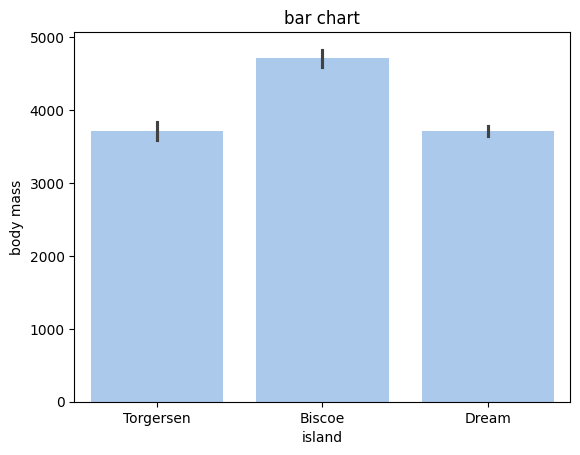

In [29]:
#loading the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#loading the inbuilt dataset of seaborn
df=sns.load_dataset("penguins")
df.head(5)
sns.set_palette("pastel")
#task 1
plt.title("bar chart")
plt.xlabel("island")
plt.ylabel("body mass")
sns.barplot(x="island",y="body_mass_g",data=df)
plt.show()



<Axes: xlabel='species', ylabel='count'>

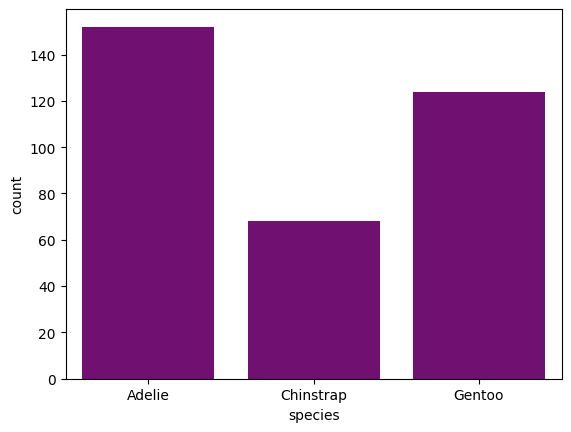

In [30]:
#task 2
sns.countplot(data=df,x="species",color="purple")

<Axes: xlabel='body_mass_g', ylabel='Count'>

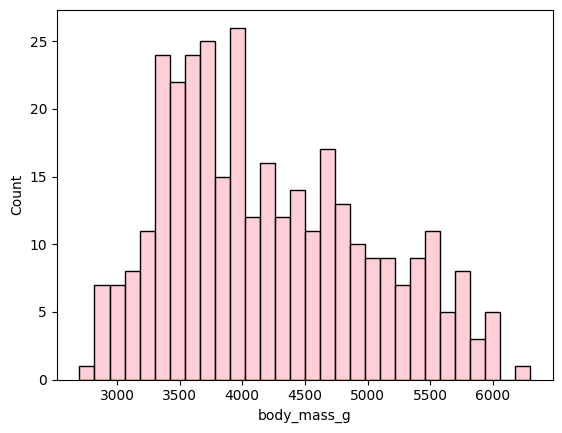

In [22]:
#task 3
sns.histplot(df,x="body_mass_g", bins=30,color='pink')


/tmp/ipykernel_624/398472518.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="body_mass_g", y="species", palette="Set3")


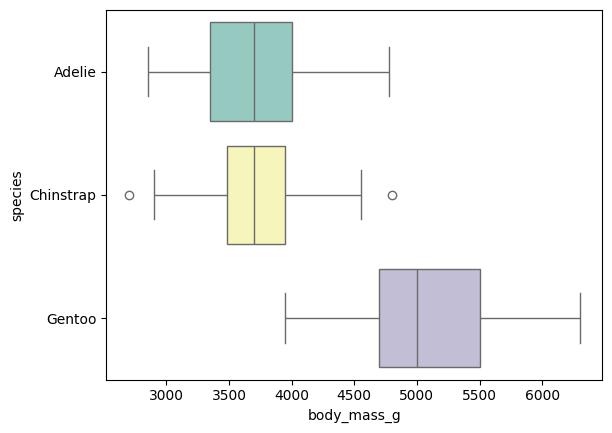

/tmp/ipykernel_624/398472518.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y="species", palette="Set2")


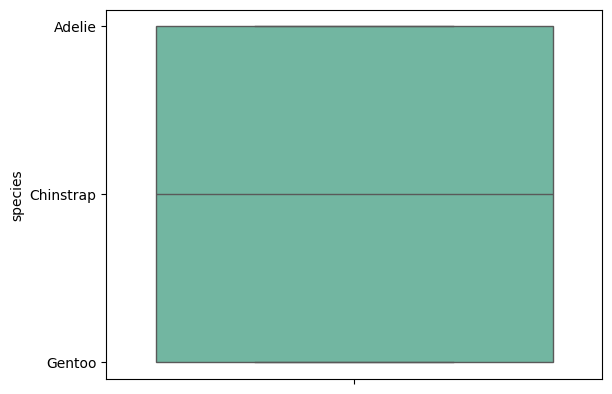

In [40]:
#task 4
sns.boxplot(data=df, x="body_mass_g", y="species", palette="Set3")
plt.show()
sns.boxplot(data=df, y="species", palette="Set2")
plt.show()




In [36]:
from numpy._core.defchararray import lower
#task 5

print("outliers for the whole dataset")

q1=df["body_mass_g"].quantile(0.25)
q3=df["body_mass_g"].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
outliers=df[(df["body_mass_g"]<lower_bound) | (df["body_mass_g"]>upper_bound)]
print(len(outliers))



print("Outliers according to species based on body_mass_g")

q1 = df.groupby("species")["body_mass_g"].transform("quantile", 0.25)
q3 = df.groupby("species")["body_mass_g"].transform("quantile", 0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = df[(df["body_mass_g"] < lower_bound)|(df["body_mass_g"] > upper_bound)]

print(outliers[["species", "body_mass_g"]])


print("yes the quartile calculation matches with the the visual outliers i can see in the box plot!")

outliers for the whole dataset
0
Outliers according to species based on body_mass_g
       species  body_mass_g
189  Chinstrap       4800.0
190  Chinstrap       2700.0
yes the quartile calculation matches with the the visual outliers i can see in the box plot!


In [47]:
#task 6
from scipy import stats
df['zscore']=stats.zscore(df["body_mass_g"])
outliers_z=df[df['zscore'].abs()>3]
print(len(outliers_z))

print("when working with zscore the outliers are identified wrt the mean of the data hence no outliers are extreme enough to be labelled as outliers on the other hand the iqr labells outliers on the basis of median which doesnt change wrt to the median")

0
when working with zscore the outliers are identified wrt the mean of the data hence no outliers are extreme enough to be labelled as outliers on the other hand the iqr labells outliers on the basis of median which doesnt change wrt to the median


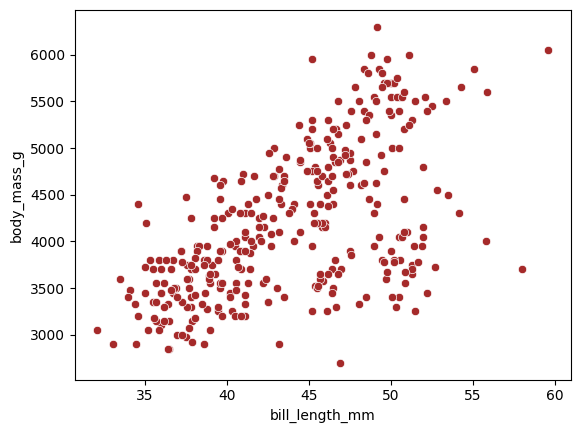

it is a positive correlation


In [52]:
#task 7
sns.scatterplot(data=df, x="bill_length_mm", y="body_mass_g",color="brown")
plt.show()
print("it is a positive correlation")

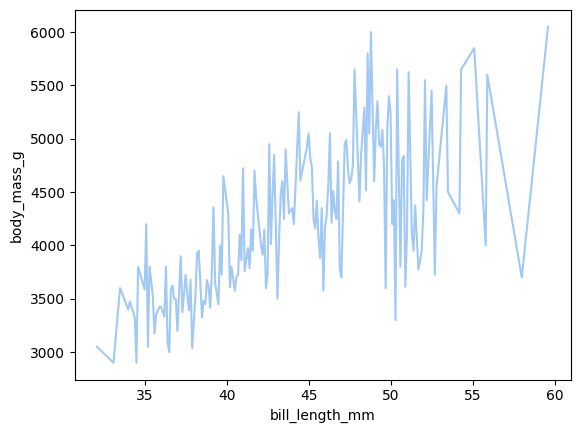

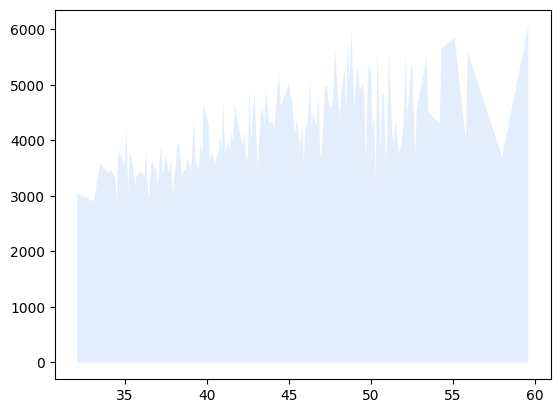

In [59]:
avg = df.groupby("bill_length_mm")["body_mass_g"].mean().reset_index()
# Line chart
sns.lineplot(data=avg, x="bill_length_mm", y="body_mass_g")
plt.show()
# Area chart
plt.fill_between(avg["bill_length_mm"], avg["body_mass_g"], alpha=0.3)
plt.show()

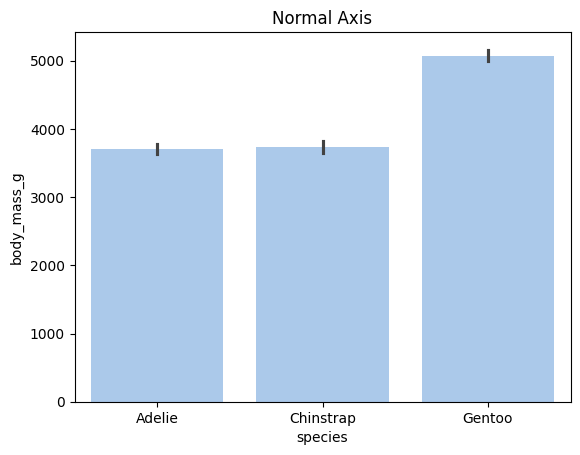

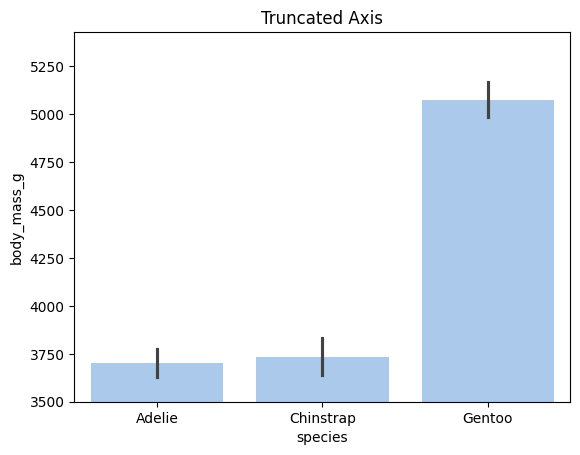

The truncated chart makes the differences between species look much larger. The data values are the same, but changing the y-axis makes the visual impression misleading.


In [58]:
#task 9
# Normal
sns.barplot(data=df, x="species", y="body_mass_g")
plt.ylim(0)
plt.title("Normal Axis")
plt.show()

# Truncated
sns.barplot(data=df, x="species", y="body_mass_g")
plt.ylim(3500)
plt.title("Truncated Axis")
plt.show()

print("The truncated chart makes the differences between species look much larger. The data values are the same, but changing the y-axis makes the visual impression misleading.")